# Predicting Diabetes Risk

#### Import dependencies

In [ ]:
#!pip install pandas scikit-learn matplotlib seaborn gradio
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr

#### Load the dataset using pandas	

In [2]:
data = pd.read_csv(r"diabetes_risk_dataset.csv")

#### Print the first few rows to inspect the data	

In [3]:
data.head()

,Age,BMI,Blood Pressure,Physical Activity (hours/week),Family History,Smoking Status,Diabetes Risk
0,48.0,19.260848,124.704947,1.756909,Yes,No,1
1,62.0,31.038294,122.348977,1.152586,Yes,No,1
2,66.0,29.817199,138.333535,0.000000,No,No,1
3,62.0,26.940032,136.166399,0.328125,Yes,Yes,1
4,38.0,25.759267,125.547778,4.683819,Yes,No,0


#### Check for any missing values

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             950 non-null    float64
 1   BMI                             950 non-null    float64
 2   Blood Pressure                  950 non-null    float64
 3   Physical Activity (hours/week)  950 non-null    float64
 4   Family History                  950 non-null    object 
 5   Smoking Status                  950 non-null    object 
 6   Diabetes Risk                   1000 non-null   int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 54.8+ KB


In [5]:
data.isna().sum()

Age                               50
BMI                               50
Blood Pressure                    50
Physical Activity (hours/week)    50
Family History                    50
Smoking Status                    50
Diabetes Risk                      0
dtype: int64

#### Handle any missing values

In [6]:
data.dropna(inplace=True)

In [7]:
data.isna().sum()

Age                               0
BMI                               0
Blood Pressure                    0
Physical Activity (hours/week)    0
Family History                    0
Smoking Status                    0
Diabetes Risk                     0
dtype: int64

#### Encode categorical columns

In [8]:
categorical_cols = ["Family History" , "Smoking Status"]
le = {}
for col in categorical_cols:
    encoder = LabelEncoder()
    data[col] = encoder.fit_transform(data[col])
    le[col] = encoder

#### Normalize or scale numeric columns

In [9]:
numerical_cols = ['Age','BMI','Blood Pressure','Physical Activity (hours/week)']

scaler = StandardScaler()
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])

#### Generate summary statistics of the dataset	

In [10]:
data.describe()

,Age,BMI,Blood Pressure,Physical Activity (hours/week),Family History,Smoking Status,Diabetes Risk
count,9.500000e+02,9.500000e+02,9.500000e+02,9.500000e+02,950.000000,950.000000,950.000000
mean,1.570673e-16,4.599829e-16,-1.851151e-16,9.162262e-17,0.455789,0.281053,0.500000
std,1.000527e+00,1.000527e+00,1.000527e+00,1.000527e+00,0.498304,0.449750,0.500263
min,-1.889151e+00,-1.873758e+00,-2.129972e+00,-1.613010e+00,0.000000,0.000000,0.000000
25%,-7.376914e-01,-7.973370e-01,-7.060864e-01,-8.267413e-01,0.000000,0.000000,0.000000
50%,-1.802943e-02,-1.137219e-01,-9.947198e-02,-1.030832e-01,0.000000,0.000000,0.500000
75%,7.735987e-01,7.093825e-01,6.456915e-01,8.104805e-01,1.000000,1.000000,1.000000
max,2.572754e+00,2.785115e+00,3.483957e+00,3.164308e+00,1.000000,1.000000,1.000000


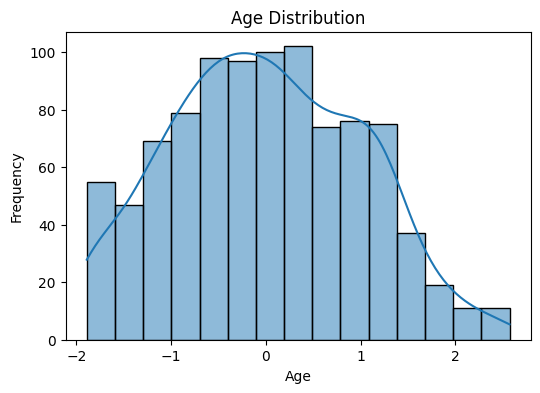

In [11]:
plt.figure(figsize=(6, 4))
sns.histplot(data["Age"], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

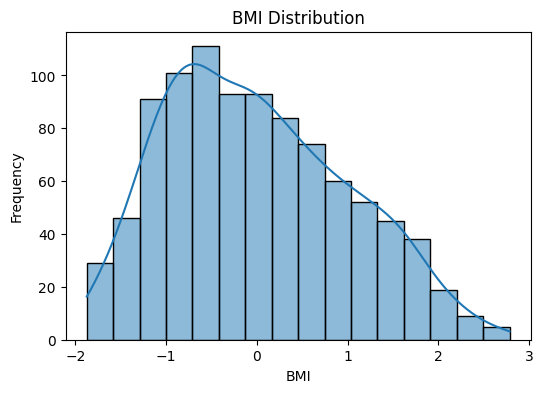

In [12]:
plt.figure(figsize=(6, 4))
sns.histplot(data["BMI"], kde=True)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

#### Separate features (X) and labels (y).

In [15]:
x = data.drop("Diabetes Risk", axis=1)
y = data["Diabetes Risk"]

#### Use train_test_split from sklearn to split the data into 80% training and 20% testing	

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#### Logistic Regression

In [17]:
lr = LogisticRegression()
lr.fit(x_train , y_train)
lr_y_pred = lr.predict(x_test)

print("Logistic Regression Metrics:")
print("Accuracy =", accuracy_score(y_test, lr_y_pred))
print("Precision =", precision_score(y_test, lr_y_pred))
print("Recall =", recall_score(y_test, lr_y_pred))
print("F1-Score =", f1_score(y_test, lr_y_pred))

Logistic Regression Metrics:
Accuracy = 0.9842105263157894
Precision = 0.989010989010989
Recall = 0.9782608695652174
F1-Score = 0.9836065573770492


#### Decision Tree Classifier

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
dt_y_pred = dt.predict(x_test)

print("Decision Tree Classifier Metrics:")
print("Accuracy =", accuracy_score(y_test, dt_y_pred))
print("Precision =", precision_score(y_test, dt_y_pred))
print("Recall =", recall_score(y_test, dt_y_pred))
print("F1-Score =", f1_score(y_test, dt_y_pred))

Decision Tree Classifier Metrics:
Accuracy = 0.9736842105263158
Precision = 0.978021978021978
Recall = 0.967391304347826
F1-Score = 0.9726775956284153


#### Generate the confusion matrix.	

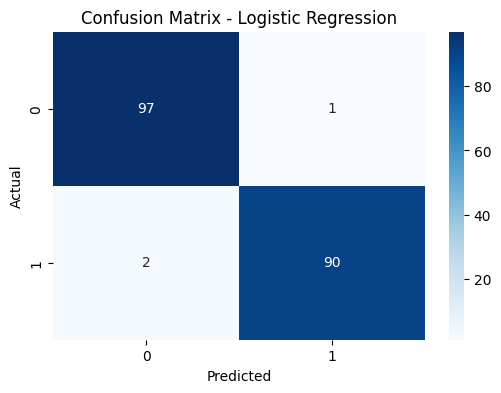

In [18]:
cm = confusion_matrix(y_test, lr_y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Use GridSearchCV or RandomizedSearchCV to find optimal parameters for models.	

In [19]:
param_grid = {
    'max_depth':[None,5,10],
    'min_samples_split':[2,5,10]
}

grid = GridSearchCV(DecisionTreeClassifier(),param_grid,cv=3)

grid.fit(x_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 5, 'min_samples_split': 10}
0.9710404282468644


In [22]:
def predict(age, bmi, bp, activity, family, smoking):

    input_data = pd.DataFrame({
        "Age":[age],
        "BMI":[bmi],
        "Blood Pressure":[bp],
        "Physical Activity (hours/week)":[activity],
        "Family History":[family],
        "Smoking Status":[smoking]
    })

    input_data[numerical_cols] = scaler.transform(input_data[numerical_cols])

    prediction = grid.predict(input_data)

    if prediction[0] == 1:
        return "Patient is at risk of Diabetes"
    else:
        return "Patient is NOT at risk of Diabetes"

In [ ]:
gr.Interface(
    fn=predict,
    inputs=[
        gr.Number(label="Age"),
        gr.Number(label="BMI"),
        gr.Number(label="Blood Pressure"),
        gr.Number(label="Physical Activity (hours/week)"),
        gr.Number(label="Family History (1=Yes,0=No)"),
        gr.Number(label="Smoking Status (1=Yes,0=No)")
    ],
    outputs="text",
    title="Diabetes Risk Prediction"
).launch()

* Running on local URL:  http://127.0.0.1:7868
* To create a public link, set `share=True` in `launch()`.
